# Phase de Data Understanding

In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

df = pd.read_csv(r'C:\Users\asmas\Documents\1-MASTER PREMIERE ANNEE\PYTHONDATA\client content\telco_customer_data_v2.csv')
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,CUST00001,Male,0,No,Yes,3.0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,68.61,205.83,Yes
1,CUST00002,Male,1,Yes,No,2.0,Yes,Yes,DSL,No,...,No internet service,Yes,NaN,No,One year,Yes,Bank transfer (automatic),23.15,46.3,No
2,CUST00003,Female,No,No,No,42.0,Yes,Yes,DSL,No,...,No,NaN,Yes,Yes,Month-to-month,No,Electronic check,42.63,1790.46,Yes
3,CUST00004,Female,0,No,Yes,40.0,Yes,Yes,Fiber optic,No,...,Yes,No,No,No internet service,Month-to-month,No,Electronic check,75.04,3001.6,No
4,CUST00005,Male,Yes,Yes,Yes,17.0,Yes,NaN,Fiber optic,Yes,...,Yes,No,No internet service,No,Two year,Yes,Electronic check,22.38,380.46,Yes
5,CUST00006,Male,0,Yes,No,18.0,Yes,No,Fiber optic,No,...,NaN,Yes,NaN,No,One year,No,Electronic check,37.23,670.14,Yes
6,CUST00007,Female,0,No,No,25.0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,67.47,1686.75,No
7,CUST00008,Female,0,Yes,No,33.0,Yes,Yes,Fiber optic,No,...,No,No,No,NaN,Two year,No,Electronic check,76.30,2517.9,No
8,CUST00009,Female,0,Yes,No,6.0,Yes,Yes,DSL,Yes,...,No,No internet service,No,No internet service,Month-to-month,No,Electronic check,64.86,389.16,No
9,CUST00010,f,0,Yes,No,-5.0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Electronic check,18.60,0,Yes


In [3]:
df.shape

(70000, 21)

### Les données ont été correctement chargées 

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        70000 non-null  object 
 1   gender            69252 non-null  object 
 2   SeniorCitizen     69341 non-null  object 
 3   Partner           66470 non-null  object 
 4   Dependents        66435 non-null  object 
 5   tenure            69433 non-null  float64
 6   PhoneService      70000 non-null  object 
 7   MultipleLines     68132 non-null  object 
 8   InternetService   70000 non-null  object 
 9   OnlineSecurity    67078 non-null  object 
 10  OnlineBackup      67253 non-null  object 
 11  DeviceProtection  67106 non-null  object 
 12  TechSupport       67267 non-null  object 
 13  StreamingTV       67173 non-null  object 
 14  StreamingMovies   67215 non-null  object 
 15  Contract          70000 non-null  object 
 16  PaperlessBilling  70000 non-null  object

On remarque que certaines features ont beaucoup de valeurs manquantes.

De plus, la plupart des features contiennent des données non numériques.

Enfin, le type de TotalCharges devrait être le même que MonthlyCharges, on le modifie :

In [5]:
#df.TotalCharges.astype(float)

Cette commande provoque une erreur : on comprend alors que certaines données de cette colonnes ne sont pas en chiffres et qu'il va falloir faire des modifications.


## On souhaite avoir une idée plus précise de chaque feature 

In [6]:
description = pd.DataFrame({ "Features" : df.columns,
                            "dtype": df.dtypes,
                            "Description" : [
    "Identifiant unique du client",  # customerID
    "Genre déclaré du client",  # gender
    "Indicateur client senior (personne âgée) (oui/non)",  # SeniorCitizen
    "Le client a un partenaire (oui/non)",  # Partner
    "Le client a des personnes à charge (oui/non)",  # Dependents
    "Ancienneté client (en mois)",  # tenure
    "Abonnement au service téléphonique (oui/non)",  # PhoneService
    "Présence de plusieurs lignes téléphoniques (oui/non)",  # MultipleLines
    "Type de service internet ",  # InternetService
    "Option sécurité en ligne incluse (oui/non / pas de service internet)",  # OnlineSecurity
    "Option sauvegarde en ligne incluse (oui/non / pas de service internet)",  # OnlineBackup
    "Option protection des appareils incluse (oui/non / pas de service internet)",  # DeviceProtection
    "Option support technique incluse (oui/non / pas de service internet)",  # TechSupport
    "Option streaming TV incluse (oui/non / pas de service internet)",  # StreamingTV
    "Option streaming films incluse (oui/non / pas de service internet)",  # StreamingMovies
    "Type/durée d’engagement contractuel (mensuel, 1 an, 2 ans, etc.)",  # Contract
    "Facturation dématérialisée (oui/non)",  # PaperlessBilling
    "Mode de paiement (chèque électronique, virement auto, carte, etc.)",  # PaymentMethod
    "Montant facturé par mois (mensualité)",  # MonthlyCharges
    "Montant total facturé cumulé sur la relation client",  # TotalCharges
    "Variable cible : client parti/résilié (oui/non)"  # Churn
]})
description

,Features,dtype,Description
customerID,customerID,object,Identifiant unique du client
gender,gender,object,Genre déclaré du client
SeniorCitizen,SeniorCitizen,object,Indicateur client senior (personne âgée) (oui/...
Partner,Partner,object,Le client a un partenaire (oui/non)
Dependents,Dependents,object,Le client a des personnes à charge (oui/non)
tenure,tenure,float64,Ancienneté client (en mois)
PhoneService,PhoneService,object,Abonnement au service téléphonique (oui/non)
MultipleLines,MultipleLines,object,Présence de plusieurs lignes téléphoniques (ou...
InternetService,InternetService,object,Type de service internet
OnlineSecurity,OnlineSecurity,object,Option sécurité en ligne incluse (oui/non / pa...


In [7]:
df.describe()

,tenure,MonthlyCharges
count,69433.000000,69612.000000
mean,30.516858,60.588548
std,89.873767,111.509588
min,-10.000000,18.000000
25%,10.000000,29.670000
50%,20.000000,41.190000
75%,35.000000,63.882500
max,999.000000,1499.770000


Il y a des valeurs incohérentes : comment l'ancienneté d'un client peut être négative ? Comment un client peut il être sous contrat depuis 999 mois, est-ce un dinosaure ?

In [8]:
df[(df.tenure < 0) ]



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
9,CUST00010,f,0,Yes,No,-5.0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Electronic check,18.60,0,Yes
20,CUST00021,Male,0,No,Yes,-10.0,Yes,No,Fiber optic,No,...,Yes,Yes,No internet service,Yes,Month-to-month,Yes,Electronic check,102.35,0,Yes
74,CUST00075,Female,NaN,Yes,No,-10.0,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),19.46,0,Yes
82,CUST00083,Male,0,No,Yes,-5.0,Yes,Yes,Fiber optic,No,...,No,Yes,No,No,Two year,Yes,Electronic check,99.35,0,No
128,CUST00129,Male,0,Yes,No,-10.0,Yes,Yes,DSL,NaN,...,No,No,No,No internet service,Month-to-month,Yes,Bank transfer (automatic),66.32,0,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69813,CUST69814,Female,0,Yes,Yes,-10.0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,49.95,0,Yes
69839,CUST69840,Male,1,Yes,No,-5.0,No,No phone service,Fiber optic,No,...,No,Yes,No,No,Month-to-month,No,Electronic check,28.26,0,Yes
69865,CUST69866,Female,0,No,No,-10.0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Electronic check,100.00,0,No
69869,CUST69870,Male,1,No,No,-10.0,Yes,No,Fiber optic,No,...,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),42.82,NaN,No


Plus de 1000 clients ont une durée de contrat mal renseignée...

In [9]:
df.isna().sum()

customerID             0
gender               748
SeniorCitizen        659
Partner             3530
Dependents          3565
tenure               567
PhoneService           0
MultipleLines       1868
InternetService        0
OnlineSecurity      2922
OnlineBackup        2747
DeviceProtection    2894
TechSupport         2733
StreamingTV         2827
StreamingMovies     2785
Contract               0
PaperlessBilling       0
PaymentMethod       3569
MonthlyCharges       388
TotalCharges        1062
Churn                  0
dtype: int64

#### pour savoir combien de valeurs il manque exactement ( 0 dans ma variable cible Churn, c'est un bon point)

## Commencons à émettre quelques hypothèse à partir de ce que l'on a avant de passer à la phase de Data Préparation

<Axes: >

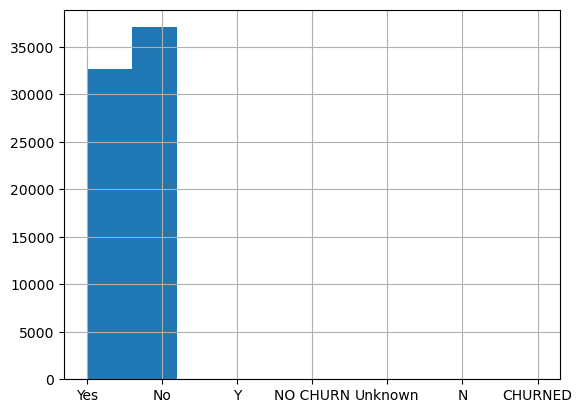

In [10]:
df.Churn.hist()

<Axes: xlabel='InternetService', ylabel='count'>

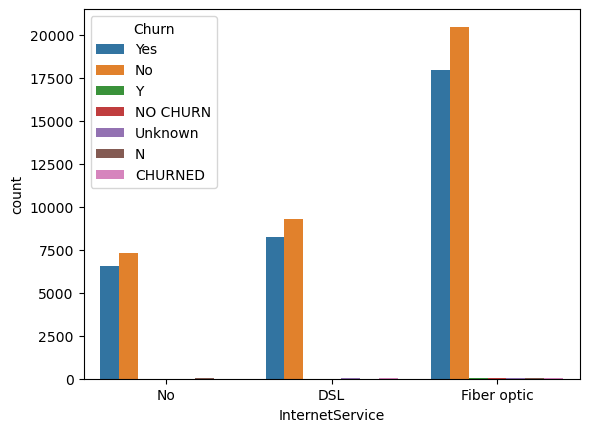

In [11]:
sns.countplot(df, x='InternetService', hue='Churn')

Le taux de résiliation est plus élevé chez les clients disposant d'une fibre optique

<Axes: xlabel='PhoneService', ylabel='count'>

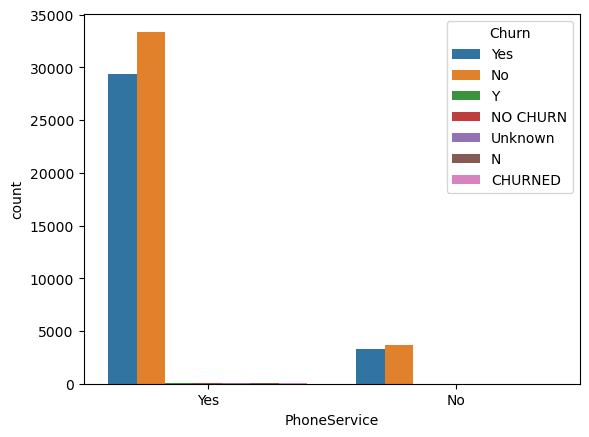

In [12]:
sns.countplot(df, x='PhoneService', hue='Churn')

Le taux de résiliation est plus élevé chez les clients disposant de l’option téléphonique

<Axes: xlabel='MultipleLines', ylabel='count'>

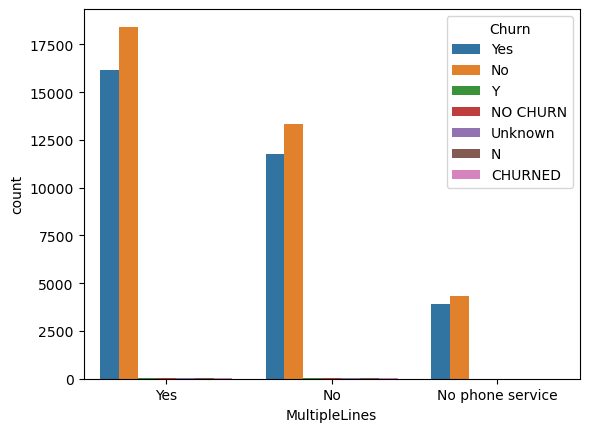

In [13]:
sns.countplot(df, x='MultipleLines', hue='Churn')

### Les options choisies ont vraissemblablement un impact moindre 

<Axes: xlabel='Partner', ylabel='count'>

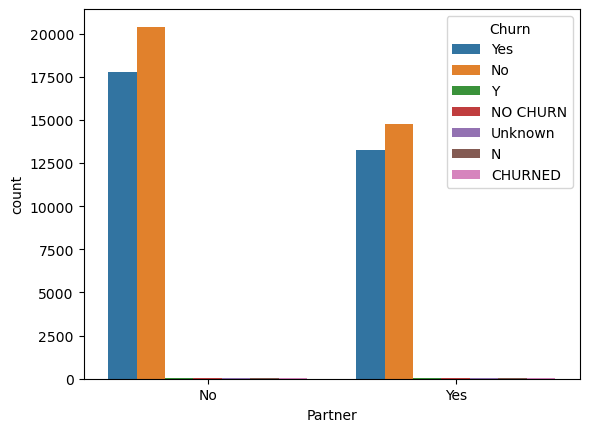

In [14]:
sns.countplot(df, x='Partner', hue='Churn')

<Axes: xlabel='tenure', ylabel='Count'>

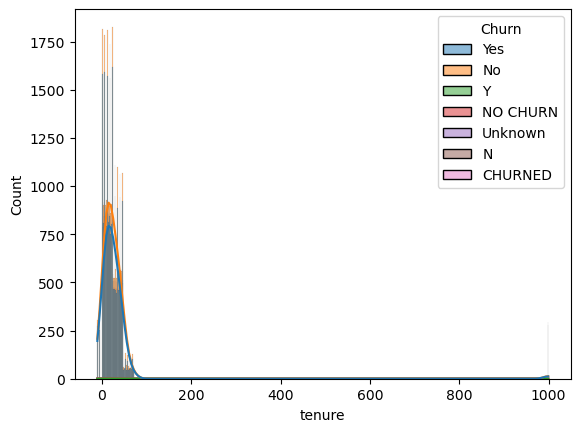

In [15]:
sns.histplot(data=df, x='tenure', hue='Churn', kde=True)

### on va nettoyer le dataset pour y voir plus clair 


# Phase de DATA Préparation et nettoyage

### Commençons par identifier les doublons

In [16]:
df.duplicated().sum()



np.int64(0)

In [17]:
#aucun doublon, 

### On a vu précedemment qu'on avait a peu près dans chaque feature 3000 valeurs manquantes

#### ---> si les trous sont sur des mêmes lignes ( i.e. des lignes entièrement non renseignées ou presque) alors ont pourra les supprimer sans remords.

#### ---> mais si ces infos manquantes sont réparties un peu partout, supprimer chaque ligne avec une valeur manquante nous fera perdre trop de données !

In [18]:
Nan_par_ligne = df.isna().sum(axis = 1)
Nan_par_ligne

0        0
1        1
2        1
3        0
4        1
        ..
69995    0
69996    1
69997    2
69998    0
69999    0
Length: 70000, dtype: int64

In [19]:
Nan_par_ligne.value_counts()

0    43995
1    20168
2     4935
3      791
4      102
5        9
Name: count, dtype: int64

### Les valeurs manquantes ont l'air d'être dispersées un peu partout, effectuer un dropna() s'avère catastrophique 

In [20]:
cata = df.dropna()
cata

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,CUST00001,Male,0,No,Yes,3.0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,68.61,205.83,Yes
3,CUST00004,Female,0,No,Yes,40.0,Yes,Yes,Fiber optic,No,...,Yes,No,No,No internet service,Month-to-month,No,Electronic check,75.04,3001.6,No
6,CUST00007,Female,0,No,No,25.0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,67.47,1686.75,No
8,CUST00009,Female,0,Yes,No,6.0,Yes,Yes,DSL,Yes,...,No,No internet service,No,No internet service,Month-to-month,No,Electronic check,64.86,389.16,No
9,CUST00010,f,0,Yes,No,-5.0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Electronic check,18.60,0,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69993,CUST69994,Male,Yes,No,No,51.0,Yes,Yes,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,38.94,1985.94 USD,Yes
69994,CUST69995,Female,Yes,No,Yes,21.0,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,One year,Yes,Electronic check,44.22,928.62,No
69995,CUST69996,Male,1,Yes,Yes,30.0,Yes,Yes,Fiber optic,Yes,...,No,Yes,No,No,Two year,No,Electronic check,74.85,2245.5,No
69998,CUST69999,Male,0,No,No,21.0,Yes,No,Fiber optic,No,...,No,No,Yes,No internet service,Month-to-month,Yes,Electronic check,46.77,982.17,No


### Cela se confirme, on a perdu plus de 25000 lignes, cela va  biaiser notre modèle ( certaines catégories de client vont être supprimeées, on aura plus une représentation réaliste de la population)

### On va devoir procéder autrement 

In [21]:
df = df.fillna('Unknown')        # On remplace les NaN par des 'Unknown'


In [22]:
df.tenure = pd.to_numeric(df.tenure, errors = 'coerce')  #on convertit en numérique la colonne tenure

In [23]:
df.MonthlyCharges = pd.to_numeric(df.MonthlyCharges, errors = 'coerce')  #on reconvertit en numérique la colonne MonthlyCharge 

In [24]:
numer = pd.to_numeric(df.TotalCharges, errors = 'coerce')
erreurs = df[(numer.isna()) & (df.TotalCharges.notnull())]
print(erreurs.TotalCharges.unique())


['716.38,USD' '1450.0$' '60.1,USD' ... '910.11,USD' '2842.56 USD'
 '1985.94 USD']


In [25]:
# il y a beaucoup de caractères unique

# D'abord, on remplace d'abord la virgule par un point  (sinon on aura des valeurs extrêmes)
df.TotalCharges = df.TotalCharges.astype(str).str.replace(',', '.', regex=False)
 
#On remplace tout ce qui n'est pas un chiffre ou un point par "rien"
# [^0-9.] signifie : "tout sauf les chiffres de 0 à 9 et le point"
df.TotalCharges = df.TotalCharges.astype(str).str.replace(r'[^0-9.]', '', regex=True)

#on peut maintenant convertir en numérique sans avoir à transformer en NaN des valeurs qui donne de l'information
df.TotalCharges = pd.to_numeric(df['TotalCharges'], errors='coerce')

df.TotalCharges 


0         205.83
1          46.30
2        1790.46
3        3001.60
4         380.46
          ...   
69995    2245.50
69996     610.05
69997     588.80
69998     982.17
69999     217.23
Name: TotalCharges, Length: 70000, dtype: float64

In [26]:
for col in df.select_dtypes( include = ['object']).columns :
    print(f"ils fait partie de nous {col}")
    print(df[col].unique())
    print("\n")
    

ils fait partie de nous customerID
['CUST00001' 'CUST00002' 'CUST00003' ... 'CUST69998' 'CUST69999'
 'CUST70000']


ils fait partie de nous gender
['Male' 'Female' 'f' 'Man' 'Unknown' 'FEMALE' 'm' 'male']


ils fait partie de nous SeniorCitizen
['0' '1' 'No' 'Yes' 'Unknown' 'not senior']


ils fait partie de nous Partner
['No' 'Yes' 'Unknown']


ils fait partie de nous Dependents
['Yes' 'No' 'Unknown']


ils fait partie de nous PhoneService
['Yes' 'No']


ils fait partie de nous MultipleLines
['Yes' 'Unknown' 'No' 'No phone service']


ils fait partie de nous InternetService
['No' 'DSL' 'Fiber optic']


ils fait partie de nous OnlineSecurity
['No internet service' 'No' 'Yes' 'Unknown' 'Y' 'True']


ils fait partie de nous OnlineBackup
['No internet service' 'No' 'Yes' 'Unknown' 'Y' 'True']


ils fait partie de nous DeviceProtection
['No internet service' 'No' 'Yes' 'Unknown' 'Y' 'True']


ils fait partie de nous TechSupport
['No internet service' 'Yes' 'Unknown' 'No' 'Y' 'True']


ils 

### On voit que plusieurs données veulent dire la  même chose, et on ne souhaite pas perdre ces informations : harmonisons tout cela 

In [27]:
df = df.replace({'nan': 'Unknown'})          #remplace les mini Nan

In [28]:
#On supprime les trous et les majuscules
col = df.select_dtypes( include = ['object']).columns
for x in col :
    df[x] = df[x].astype(str).str.lower().str.strip()

In [29]:
#pour le genre ['Male' 'Female' 'f' 'Man' 'Unknown' 'FEMALE' 'm' 'male']
df['gender'] = df['gender'].replace({ 'male' : 'm',
                 'man' : 'm',
                 'female' : 'f'})

# pour les seniors SeniorCitizen ['0' '1' 'No' 'Yes' 'Unknown' 'not senior']
df['SeniorCitizen'] = df['SeniorCitizen'].replace({'no' : '0', 
                                     'yes': '1',
                                     'not senior' : '0'})

# pour les options  ['No internet service' 'No' 'Yes' 'Unknown' 'Y' 'True']
df.OnlineSecurity = df.OnlineSecurity.replace({'yes' : 'y',
                                 'true': 'y'})

df.OnlineBackup = df.OnlineBackup.replace({'yes' : 'y',
                                 'true': 'y'})

df.DeviceProtection = df.DeviceProtection.replace({'yes' : 'y',
                                 'true': 'y'})

df.TechSupport = df.TechSupport.replace({'yes' : 'y',
                                 'true': 'y'})

df.StreamingTV = df.StreamingTV.replace({'yes' : 'y',
                                 'true': 'y'})

df.StreamingMovies = df.StreamingMovies.replace({'yes' : 'y',
                                 'true': 'y'})

df.Contract = df.Contract.replace({'month-to-month' : 'm-m'})


df.Churn = df.Churn.replace({'yes' : 'y',
                        'churned': 'y',
                         'no': 'n',
                          'no churn': 'n',
                          })

df.PaymentMethod = df.PaymentMethod.replace({'Bank transfer (automatic)' : 'bank transfer'})              #on a unifié bank transfer et bank transfer automatic quis elon moi signifie la mm chose



In [30]:
for col in df.select_dtypes( include = ['object']).columns :
    print(f"ils fait partie de nous {col}")
    print(df[col].unique())
    print("\n")
    

ils fait partie de nous customerID
['cust00001' 'cust00002' 'cust00003' ... 'cust69998' 'cust69999'
 'cust70000']


ils fait partie de nous gender
['m' 'f' 'unknown']


ils fait partie de nous SeniorCitizen
['0' '1' 'unknown']


ils fait partie de nous Partner
['no' 'yes' 'unknown']


ils fait partie de nous Dependents
['yes' 'no' 'unknown']


ils fait partie de nous PhoneService
['yes' 'no']


ils fait partie de nous MultipleLines
['yes' 'unknown' 'no' 'no phone service']


ils fait partie de nous InternetService
['no' 'dsl' 'fiber optic']


ils fait partie de nous OnlineSecurity
['no internet service' 'no' 'y' 'unknown']


ils fait partie de nous OnlineBackup
['no internet service' 'no' 'y' 'unknown']


ils fait partie de nous DeviceProtection
['no internet service' 'no' 'y' 'unknown']


ils fait partie de nous TechSupport
['no internet service' 'y' 'unknown' 'no']


ils fait partie de nous StreamingTV
['no internet service' 'unknown' 'y' 'no']


ils fait partie de nous StreamingMovi

## Et voila, c'est déjà beacoup plus propre

### Mais attention, finalement, il y a bien des valeurs manquantes cachés dans ma feature Churn : les valeurs Unknown et je n'en veux pas.

In [31]:
df = df[df['Churn'] != 'unknown']


In [32]:
#regardons les observations de client ou l'ancienneté du contrat est inférieure à 0 ( il n' y en a que 1000) et supposons que notre compagnie acceuille ses client depuis 40 ans)
df[(df['tenure'] >= 0) & (df['tenure'] < 40*12) ]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,cust00001,m,0,no,yes,3.0,yes,yes,no,no internet service,...,no internet service,no internet service,no internet service,no internet service,m-m,no,mailed check,68.61,205.83,y
1,cust00002,m,1,yes,no,2.0,yes,yes,dsl,no,...,no internet service,y,unknown,no,one year,yes,bank transfer (automatic),23.15,46.30,n
2,cust00003,f,0,no,no,42.0,yes,yes,dsl,no,...,no,unknown,y,y,m-m,no,electronic check,42.63,1790.46,y
3,cust00004,f,0,no,yes,40.0,yes,yes,fiber optic,no,...,y,no,no,no internet service,m-m,no,electronic check,75.04,3001.60,n
4,cust00005,m,1,yes,yes,17.0,yes,unknown,fiber optic,y,...,y,no,no internet service,no,two year,yes,electronic check,22.38,380.46,y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,cust69996,m,1,yes,yes,30.0,yes,yes,fiber optic,y,...,no,y,no,no,two year,no,electronic check,74.85,2245.50,n
69996,cust69997,m,0,yes,unknown,15.0,yes,yes,fiber optic,no,...,no,no,no,no,m-m,yes,bank transfer (automatic),40.67,610.05,y
69997,cust69998,m,0,unknown,no,20.0,yes,no,dsl,y,...,no,no,unknown,no,m-m,yes,mailed check,29.44,588.80,n
69998,cust69999,m,0,no,no,21.0,yes,no,fiber optic,no,...,no,no,y,no internet service,m-m,yes,electronic check,46.77,982.17,n


In [33]:
#cela represente 3% des clients, je fais le choix de remplacer par la moyenne, leurs autres features sont peut être extrêmes et donc importantes pour l'algo
vrai_tenure = df.loc[(df['tenure'] >= 0) & (df['tenure'] < 40*12), 'tenure'].mean().round(0)                    #round pour prendre la partie entière du mois
df.loc[~((df['tenure'] >= 0) & (df['tenure'] < 40*12)), 'tenure'] = vrai_tenure
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,cust00001,m,0,no,yes,3.0,yes,yes,no,no internet service,...,no internet service,no internet service,no internet service,no internet service,m-m,no,mailed check,68.61,205.83,y
1,cust00002,m,1,yes,no,2.0,yes,yes,dsl,no,...,no internet service,y,unknown,no,one year,yes,bank transfer (automatic),23.15,46.30,n
2,cust00003,f,0,no,no,42.0,yes,yes,dsl,no,...,no,unknown,y,y,m-m,no,electronic check,42.63,1790.46,y
3,cust00004,f,0,no,yes,40.0,yes,yes,fiber optic,no,...,y,no,no,no internet service,m-m,no,electronic check,75.04,3001.60,n
4,cust00005,m,1,yes,yes,17.0,yes,unknown,fiber optic,y,...,y,no,no internet service,no,two year,yes,electronic check,22.38,380.46,y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,cust69996,m,1,yes,yes,30.0,yes,yes,fiber optic,y,...,no,y,no,no,two year,no,electronic check,74.85,2245.50,n
69996,cust69997,m,0,yes,unknown,15.0,yes,yes,fiber optic,no,...,no,no,no,no,m-m,yes,bank transfer (automatic),40.67,610.05,y
69997,cust69998,m,0,unknown,no,20.0,yes,no,dsl,y,...,no,no,unknown,no,m-m,yes,mailed check,29.44,588.80,n
69998,cust69999,m,0,no,no,21.0,yes,no,fiber optic,no,...,no,no,y,no internet service,m-m,yes,electronic check,46.77,982.17,n


## Passons à la mise à l'échelle des variables Monthly Charges TotalCharges et tenure ( pour que l'algo leur accorde la même importance)

In [35]:
df.describe()

,tenure,MonthlyCharges,TotalCharges
count,69946.000000,69558.000000,6.792600e+04
mean,22.944028,60.580597,1.807040e+03
std,15.081310,111.477545,9.675831e+03
min,1.000000,18.000000,0.000000e+00
25%,11.000000,29.670000,3.802100e+02
50%,21.000000,41.190000,8.217800e+02
75%,34.000000,63.880000,1.539765e+03
max,72.000000,1499.770000,1.244434e+06


#### on regarde les statistiques de mon dataset maintenant que celui ci est nettoyé : les moyennes semblent cohérentes ( 22 mois de contrats, 60 euro mensuels, un total de 1800 euros ~ 60e * 22 mois)

on remarque néanmoins qu'on a une grosse variance, surement provoqué par des erreurs/cas extrêmes et que le min du totalCharge est incohérent par rapport à Monthly Charge car inférieur 

In [37]:
#trouvons le vrai min de totalCharges
les_mins = df[df.MonthlyCharges < df.TotalCharges].groupby('tenure')['TotalCharges'].min()    # on regroupe par mois et on regarde le min pour chaque mois ( sur les données coherentes ( total > mois)
les_mins.sort_values()



tenure
15.0      21.26
10.0      31.34
18.0      35.68
48.0      35.72
2.0       36.10
         ...   
70.0    1290.10
68.0    1292.00
69.0    1298.58
72.0    1306.08
71.0    1315.63
Name: TotalCharges, Length: 72, dtype: float64

In [38]:
df[((df.TotalCharges < 22) & (df.TotalCharges > 21)) & (df.tenure > 1)]  #voila 2 coupables

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
38880,cust38881,m,0,yes,no,15.0,yes,no,fiber optic,unknown,...,no,no internet service,no,no,m-m,yes,bank transfer (automatic),19.60,21.26,y
40064,cust40065,f,0,no,yes,37.0,yes,yes,fiber optic,no,...,unknown,no,y,no,m-m,yes,electronic check,45.28,21.34,y


### Comment le min des charges mensuels est 18, et des clients qui restent 15 mois peuvent avoir un total de 21euros : des données ont été mal renseignées

### Corrigeons cela : pour chaque TotalCharge incohérent, on le remplace par la formule simple : (nb de mois)*(prix mensuel) (plutot que de supprimer et éviter une perte de données)

In [39]:
mauvais_msk = df.TotalCharges < ((df.tenure * df.MonthlyCharges) - ((df.tenure // 3)*df.MonthlyCharges))           #(df.tenure // 3)*df.MonthlyCharges est l'erreur que j'autorise : c'est pas grave si il n'a pas payé 1 tiers des mois, c'est peut être une promo ou un geste commercial
df.loc[mauvais_msk, 'TotalCharges'] = df.tenure * df.MonthlyCharges


In [40]:
df[((df.TotalCharges < 22) & (df.TotalCharges > 21)) & (df.tenure > 1)] 

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [41]:
#hourraa !
#voyons maintenant nos nouvelles statistiques
df.describe()


,tenure,MonthlyCharges,TotalCharges
count,69946.000000,69558.000000,6.792600e+04
mean,22.944028,60.580597,1.838115e+03
std,15.081310,111.477545,9.681053e+03
min,1.000000,18.000000,0.000000e+00
25%,11.000000,29.670000,4.124400e+02
50%,21.000000,41.190000,8.477950e+02
75%,34.000000,63.880000,1.563933e+03
max,72.000000,1499.770000,1.244434e+06


In [42]:
#le min vaut 0 à cause de ces deux éléments récalicitrant dont aucune données financière n'est renseignée, supprimons les
df[df['TotalCharges'] < 18]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7313,cust07314,f,0,yes,no,23.0,yes,no,no,no internet service,...,no internet service,no internet service,no internet service,no internet service,two year,no,mailed check,NaN,0.0,n
36810,cust36811,m,0,no,yes,23.0,yes,yes,fiber optic,no,...,no,y,unknown,no,one year,no,bank transfer (automatic),NaN,0.0,y


In [43]:
df = df.drop([7313, 36810])
df[df['TotalCharges'] < 18]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [44]:
df.describe()

,tenure,MonthlyCharges,TotalCharges
count,69944.000000,69558.000000,6.792400e+04
mean,22.944027,60.580597,1.838169e+03
std,15.081525,111.477545,9.681190e+03
min,1.000000,18.000000,1.802000e+01
25%,11.000000,29.670000,4.124400e+02
50%,21.000000,41.190000,8.478000e+02
75%,34.000000,63.880000,1.563955e+03
max,72.000000,1499.770000,1.244434e+06


## Là, on est cohérent. On peut mettre à l'échelle correctement.

In [45]:
#mise à l'échelle, on va à présent transformer les valeurs pour qu'elles ait du sens pour l'algo et pour que l'on y retrouve un sens, je vais stocker le dataframe au préalable
df_visu = df.copy()

df.MonthlyCharges = df.MonthlyCharges.map(lambda x : (x - df.MonthlyCharges.min())/ (df.MonthlyCharges.max() - df.MonthlyCharges.min()))       #coute cher en calcul, j'aurai pu stocker mes variables au préalable

In [46]:
minT = df.TotalCharges.min()
maxT = df.TotalCharges.max()

df.TotalCharges = df.TotalCharges.map(lambda x : (x - minT)/ ( maxT - minT))

In [47]:
mint = df.tenure.min()
maxt = df.tenure.max()

df.tenure = df.tenure.map(lambda x : (x - mint)/ (maxt - mint))


## On peut maintenant tenter de vraiment voir ce qui se passe maintenant que notre Dataset est bien nettoyé

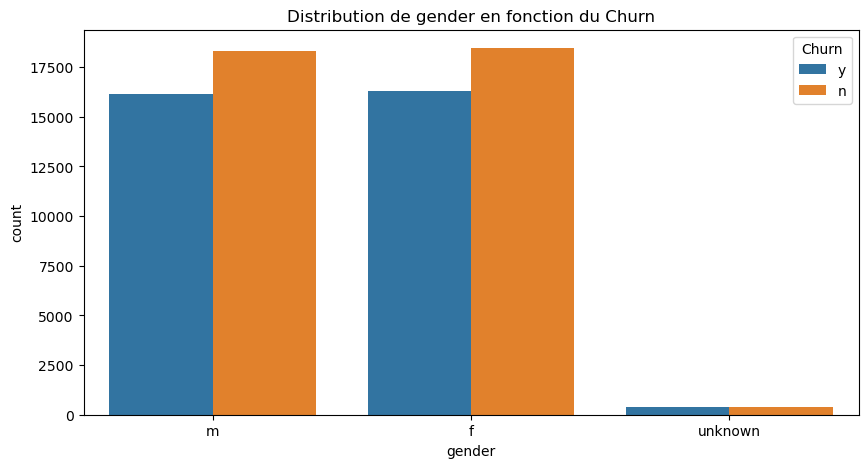

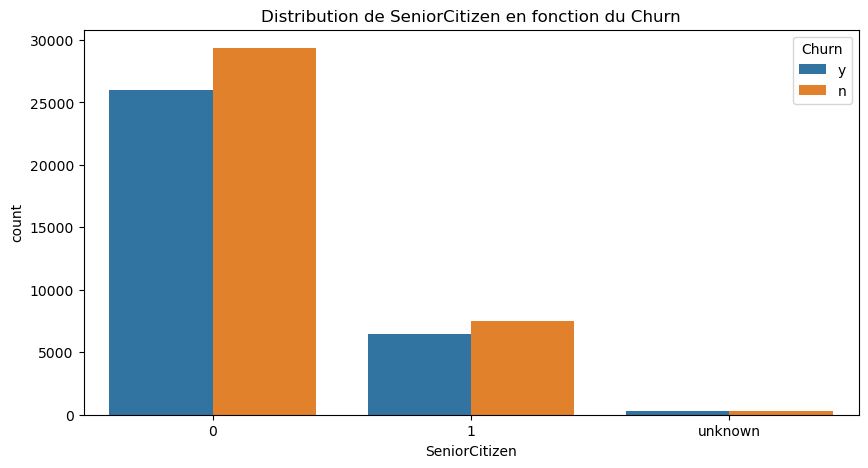

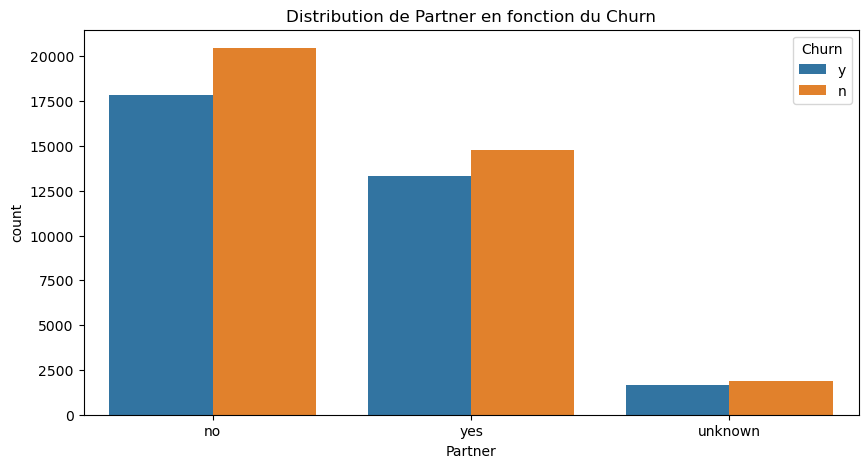

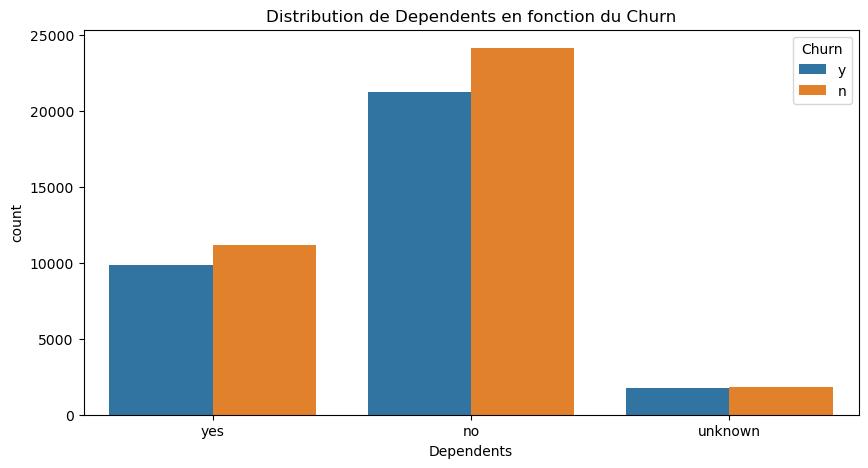

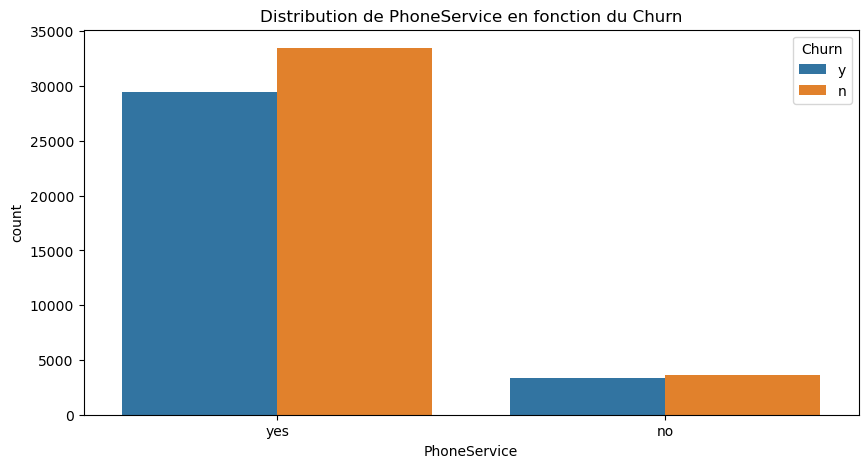

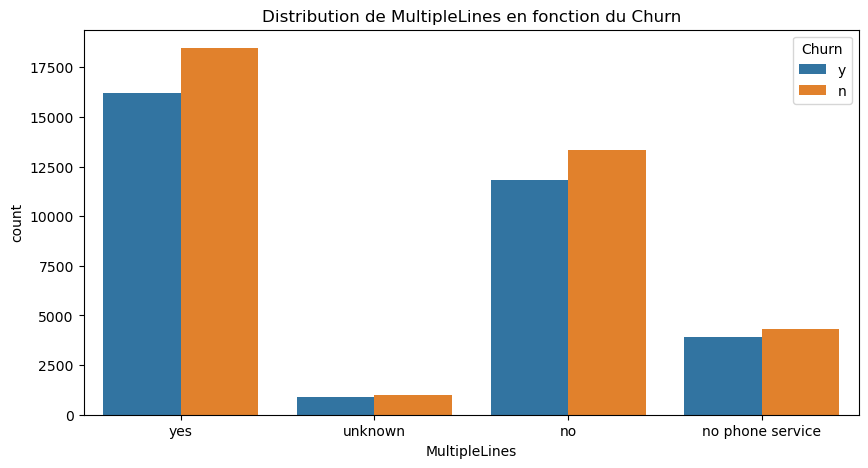

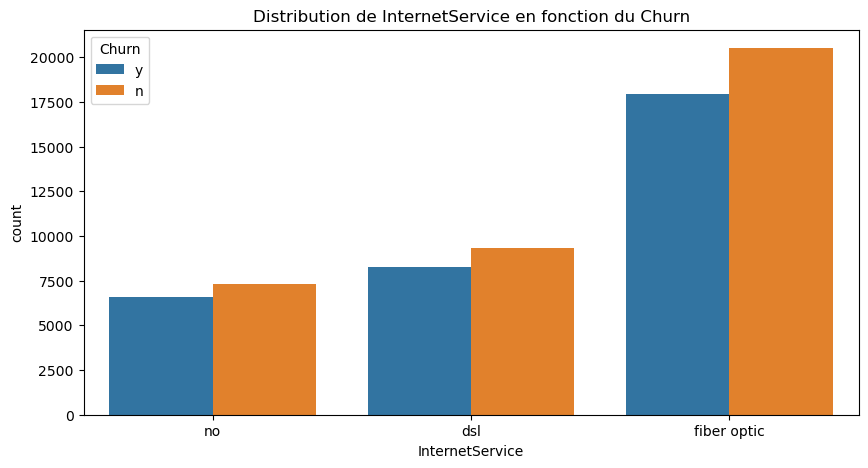

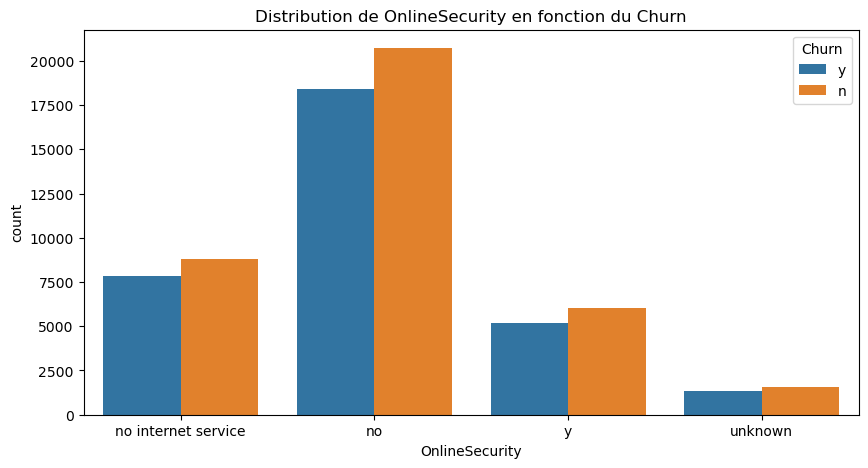

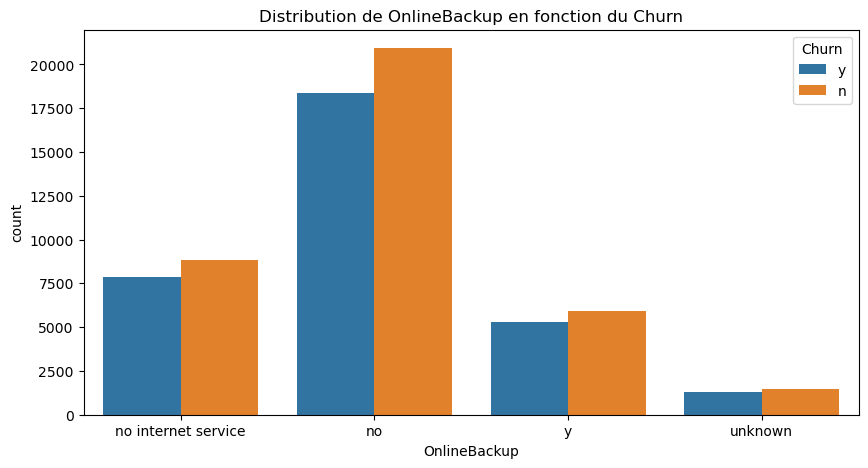

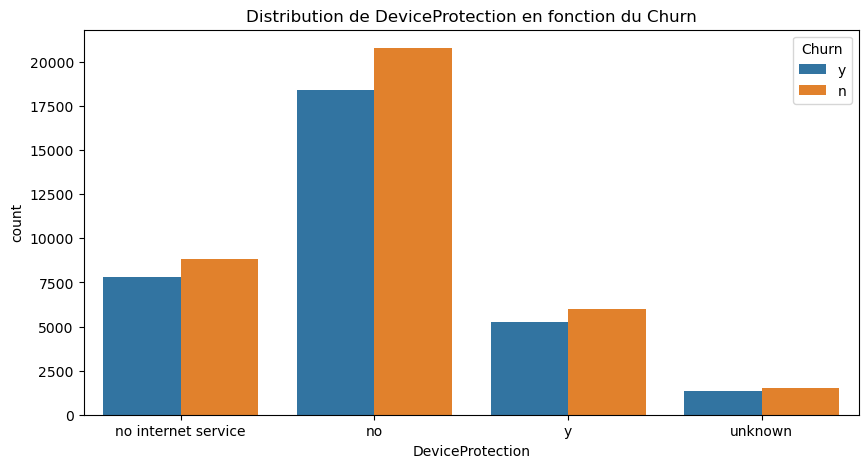

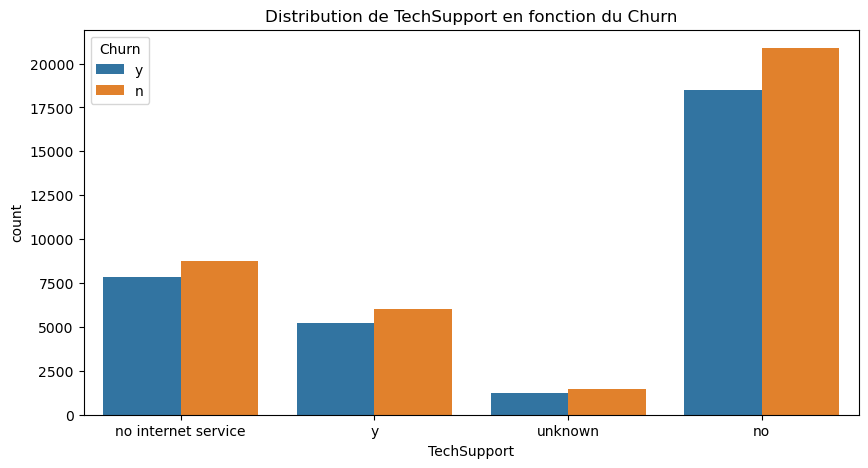

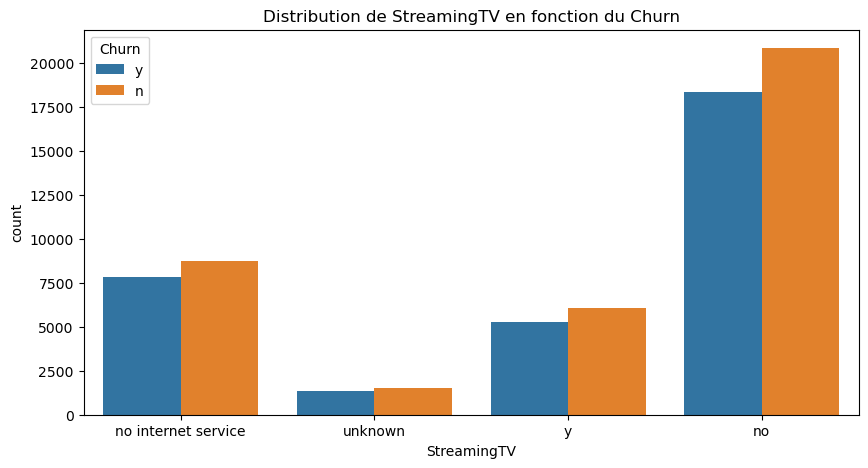

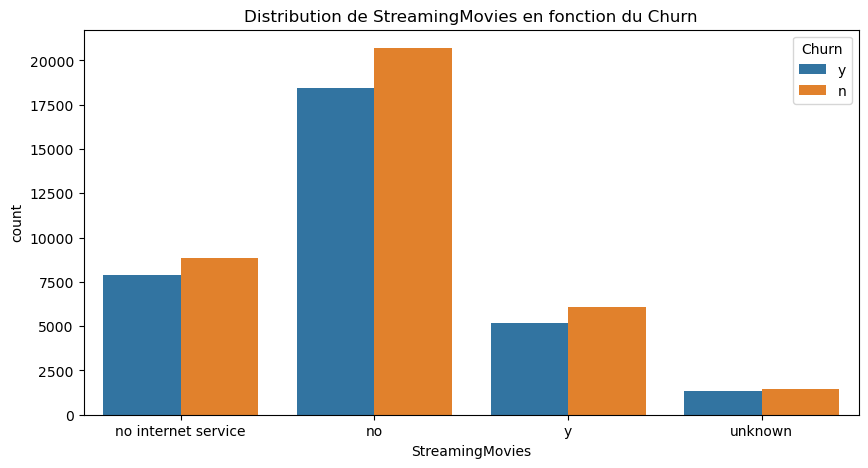

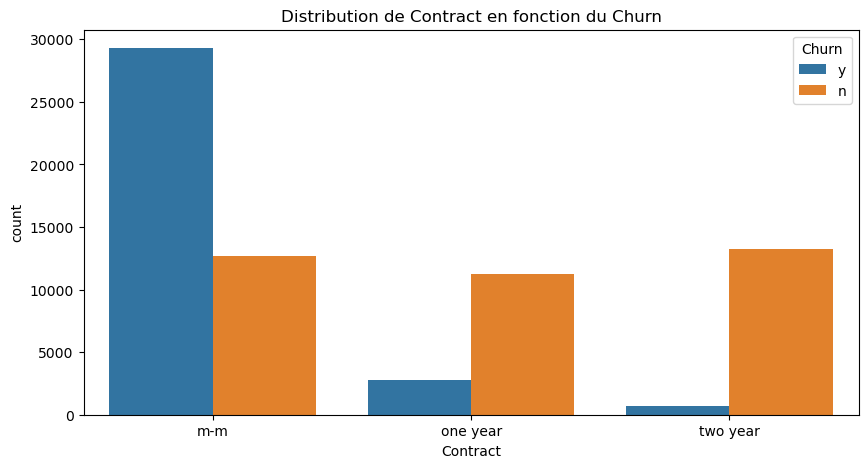

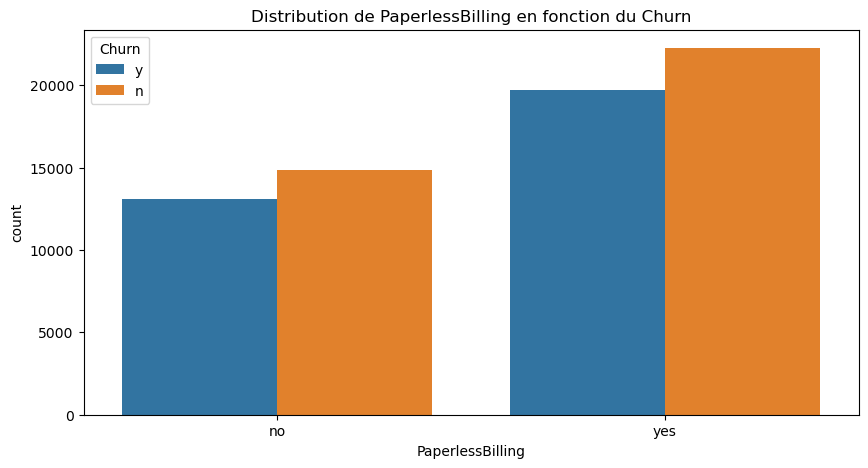

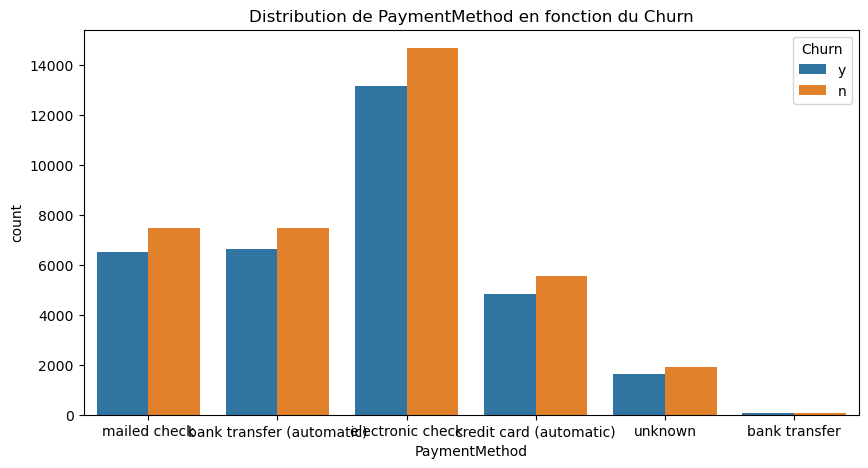

In [48]:
for elem in ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies','Contract', 'PaperlessBilling', 'PaymentMethod'] :
    plt.figure(figsize=(10, 5))
    sns.countplot(df, x= elem, hue='Churn')
    plt.title(f"Distribution de {elem} en fonction du Churn")
    plt.show()

### Et on y vois enfin beaucoup plus clair ! Les contrats longues durée ont beaucoup de succès : 4 clients sur 5 continuent après un contrat de 1 an et environ 14 clients sur 15 continuent après un contrat de 2 ans. Tandis que 2 tiers des clients qui résilient ont un contrat au mois !

In [49]:
df_visu.tenure

0         3.0
1         2.0
2        42.0
3        40.0
4        17.0
         ... 
69995    30.0
69996    15.0
69997    20.0
69998    21.0
69999     3.0
Name: tenure, Length: 69944, dtype: float64

<Axes: xlabel='tenure', ylabel='Count'>

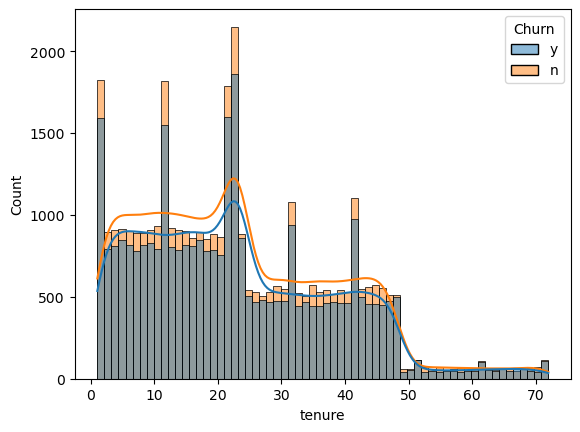

In [50]:
sns.histplot(data=df, x=df_visu.tenure, hue='Churn', kde=True)

In [51]:
#je trouve que le graphique ne coincide pas avec ma trouvaille des contrat longue durée : on devrait voirun tendance s'inverser après un an 
df_visu[(df_visu['Contract'] == 'two year') & (df_visu.tenure < 24)]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
4,cust00005,m,1,yes,yes,17.0,yes,unknown,fiber optic,y,...,y,no,no internet service,no,two year,yes,electronic check,22.38,380.46,y
14,cust00015,m,0,yes,no,8.0,yes,yes,fiber optic,y,...,y,no,no,no,two year,no,credit card (automatic),53.36,426.88,n
22,cust00023,m,0,yes,no,21.0,yes,yes,fiber optic,y,...,no,y,no,no,two year,yes,bank transfer (automatic),36.96,776.16,y
26,cust00027,m,0,no,no,5.0,yes,yes,no,no internet service,...,no internet service,no internet service,no internet service,no internet service,two year,yes,mailed check,43.36,216.80,n
29,cust00030,m,0,yes,no,10.0,yes,no,fiber optic,y,...,y,no,no,no,two year,no,mailed check,115.47,1154.70,n
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69951,cust69952,m,0,no,no,19.0,yes,yes,dsl,no,...,no,no,no,no,two year,yes,bank transfer (automatic),45.71,868.49,n
69967,cust69968,f,0,no,no,14.0,yes,yes,no,no internet service,...,no internet service,no internet service,no internet service,no internet service,two year,no,electronic check,44.41,621.74,n
69976,cust69977,f,0,no,no,3.0,yes,yes,dsl,no,...,no,unknown,no,y,two year,yes,electronic check,42.07,126.21,n
69977,cust69978,f,0,yes,no,13.0,no,no phone service,fiber optic,no,...,no,unknown,y,no,two year,no,electronic check,38.24,497.12,n


### Voila le piège ! Plusieurs client ont souscris 2 ans mais n'y sont pas encore. Et c'est parmi ce groupe que l'on trouve le moins de résiliation. On en déduit que l'engagement long terme est un excellent moyen de conserver le client. 

## Maintenant on va transformer les valeurs catégorielle en valeurs numérique afin de les rendre lisible par l'algorithme 

In [52]:
# On liste les colonnes nominales
categ = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies','Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']   

# On encode en évitant la redondance
df = pd.get_dummies(df, columns=categ, drop_first=True)
df = df.drop( columns = ['customerID'])

## On va pouvoir séparer le dataset en Train vs Test

In [53]:
#avant tout, séparons les features X de ma variable cible : le label y
X = df.drop(columns = ['Churn_y'])
y = df['Churn_y']

# On sépare : 80 % pour le train, 20% pour le test, on fait cela pour que l'on ne test pas l'algo sur des données sur lequelles il s'est entrainé, pour eviter qu'il ne performe que sur celui ci
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


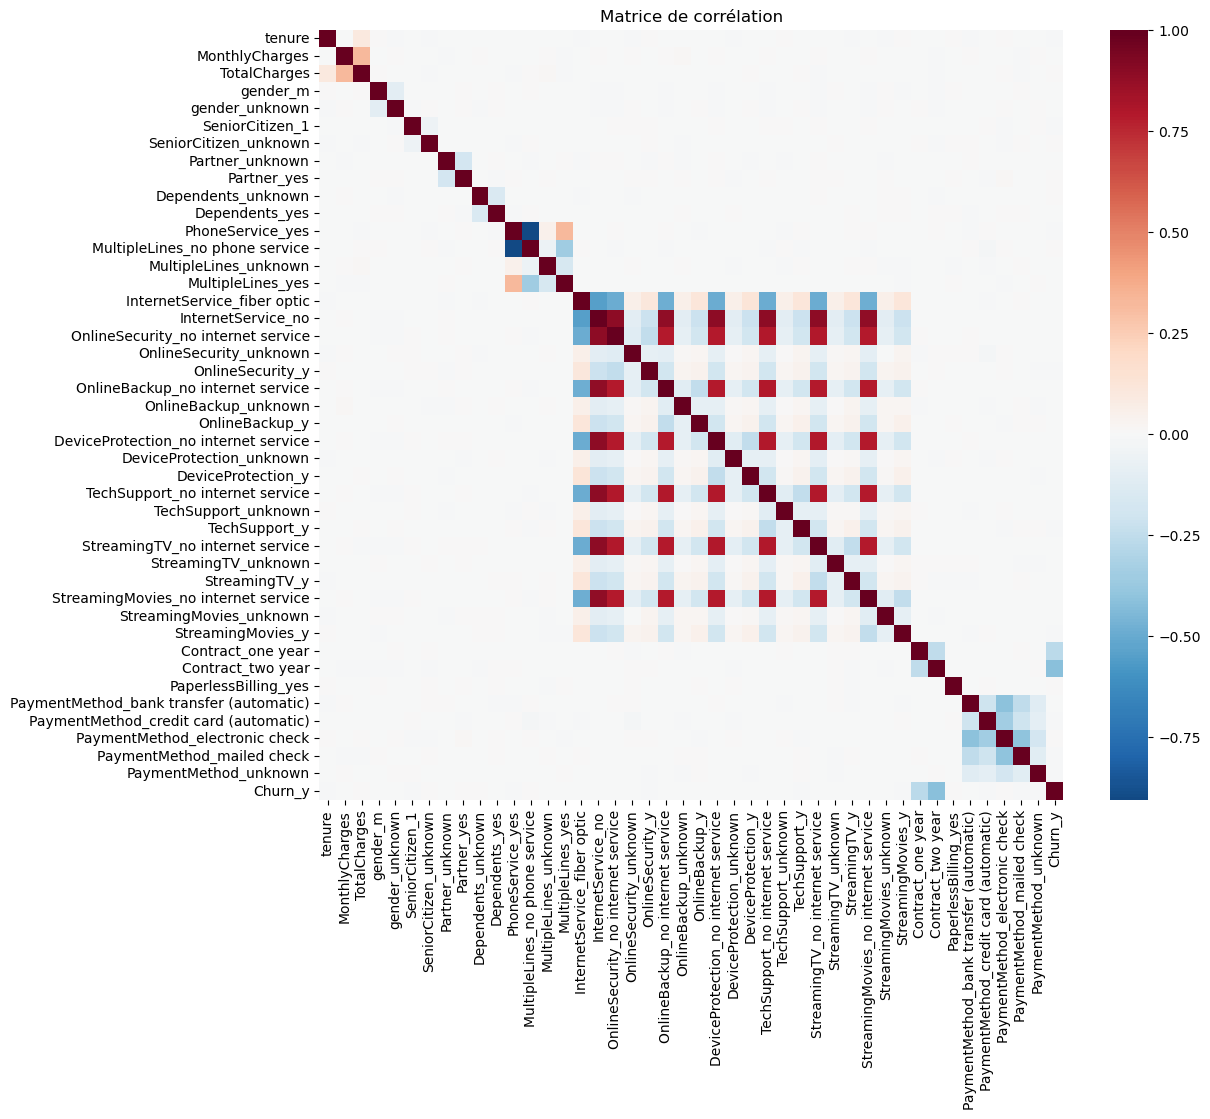

In [54]:
#utilisons la matrice de corrélation
df_train = pd.concat([X_train, y_train], axis=1)
corre = df_train.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corre, cmap='RdBu_r', center=0)
plt.title("Matrice de corrélation")
plt.show()

In [55]:
# plusieurs variables sont logiquement corrélés , exemple: si je n'ai pas l'option internet, je suis systèmatiquement categorisé comme 'pas de service internet' dans la variable online sécurity
# on voit que la durée du contrat est corrélé à la résiliation du contrat ce qui coïncide avec nos hypothèses précédentes. 

In [56]:
# 1. Créer le modèle (on l'appelle "clf" pour classifier)
clsf = RandomForestClassifier(random_state=42)

# 2. L'entraîner (C'est ici que l'ordi réfléchit)
clsf.fit(X_train, y_train)

# 3. Faire des prédictions sur les données qu'il ne connaît pas
y_pred = clsf.predict(X_test)

# 4. Regarder si c'est bon
print(f"Précision du modèle : {accuracy_score(y_test, y_pred):.2%}")
print(classification_report(y_test, y_pred))

Précision du modèle : 75.77%
              precision    recall  f1-score   support

       False       0.84      0.67      0.75      7445
        True       0.69      0.86      0.77      6544

    accuracy                           0.76     13989
   macro avg       0.77      0.76      0.76     13989
weighted avg       0.77      0.76      0.76     13989

